# Convex regression in high dimensions — $f(x) = \|x\|_2^2$ in $d = 50$

This notebook is a self-contained, publicly-runnable version of the regression
experiment in our work "Hyper Input Convex Neural Networks for Shape Constrained Learning and Optimal Transport". 

It trains four architectures on noisy
observations of a convex quadratic target in $\mathbb{R}^{50}$ and compares

1. how quickly each architecture drives the **noiseless test loss** down, and
2. how each learned function extrapolates along random rays (_rotational profile_).

---

## 1.1 · The statistical model

Let $d = 50$ be the input dimension and $n = 5\,000$ the training sample size.
The data are i.i.d. draws

$$X_i \stackrel{\text{iid}}{\sim} \mathrm{Uniform}\big([-1, 1]^d\big),
\qquad
\varepsilon_i \stackrel{\text{iid}}{\sim} \mathcal{N}(0, \sigma^2),
\qquad \sigma = 1,$$

and the observations satisfy

$$Y_i \;=\; f(X_i) + \varepsilon_i,
\qquad
f : \mathbb{R}^d \to \mathbb{R},\quad
f(x) \;=\; \sum_{j=1}^{d} x_j^2 \;=\; \|x\|_2^2.$$

The target $f$ is convex, coercive and smooth — a canonical test-bed for
convex-by-construction estimators.

## 1.2 · The learning problem

Given $(X_i, Y_i)_{i=1}^n$ we train a neural network $\hat f_\theta$ by
empirical risk minimisation under squared loss,

$$\widehat\theta \;\in\; \underset{\theta}{\arg\min}\;
\frac{1}{n}\sum_{i=1}^{n} \big( \hat f_\theta(X_i) - Y_i \big)^2.$$

Performance is evaluated on **independent, noiseless** samples

$$X_i^{\text{pred}} \stackrel{\text{iid}}{\sim} \mathrm{Uniform}([-1,1]^d),
\qquad Y_i^{\text{pred}} = f(X_i^{\text{pred}}),$$

giving the _prediction MSE_

$$\mathcal{L}_{\text{pred}}(\hat f) \;=\;
\frac{1}{n_{\text{pred}}}\sum_{i=1}^{n_{\text{pred}}}
\big(\hat f(X_i^{\text{pred}}) - f(X_i^{\text{pred}})\big)^2.$$

This is a Monte-Carlo estimate of $\mathbb{E}_{X}\big[(\hat f(X) - f(X))^2\big]$
and is the quantity plotted per epoch below.

## 1.3 · Architectures under test

| Name | Description | Hidden dims | Convex in $x$? |
|:---|:---|:---|:---:|
| **MLP**         | ReLU multilayer perceptron                                        | `[64,64,64,64]` | — |
| **ICNN**        | Input-Convex NN with `icnn_zero` init (x→z skip weights zeroed)    | `[64,64,64,64]` | ✓ |
| **GroupMaxNet** | Constrained Maxout network, no input skip                                      | `[48,48,48,48]` | ✓ |
| **HyCNN**       | Hyper Input Convex NN = maxout gates + input skip  | `[48,48,48,48]` | ✓ |

All four architectures are defined from scratch in the notebook (no local
imports from the host repository).


In [43]:
# =============================================================================
# 0. Imports
# =============================================================================
# Only stdlib + the standard scientific Python stack. No local imports: every
# architecture is defined further down so the notebook is fully self-contained.
import math
from typing import Sequence, Callable, List, Tuple

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
plt.style.use("seaborn-v0_8-whitegrid")


# =============================================================================
# Color scheme — matches "FIG - notebooks/FIG_1_model_visualization_mse_rotational.ipynb"
# =============================================================================
#   family_palette = {
#       "HyCNN": "#0080db",   # blue
#       "ICNN":  "#f3a11c",   # amber
#       "MLP":   "#e330f0",   # magenta
#   }
# GroupMaxNet is not part of the FIG_1 figures; we give it the next colour from
# the FIG_1 fallback palette (#2ca02c, green).
FAMILY_COLORS = {
    "MLP":         "#e330f0",   # magenta
    "ICNN":        "#f3a11c",   # amber
    "GroupMaxNet": "#2ca02c",   # green  (fallback slot from FIG_1 notebook)
    "HyCNN":       "#0080db",   # blue
}

# Draw order: deepest-on-top means HyCNN (blue) and GroupMaxNet (green) sit
# above the MLP baseline in the legend.
DISPLAY_ORDER = ["MLP (64x4)",
                 "MLP (64x8)",
                 "MLP (64x16)", 
                 "ICNN (64x4)", 
                 "ICNN (64x8)", 
                 "ICNN (64x16)", 
                 "GroupMaxNet (48x4)",
                 "GroupMaxNet (48x8)", 
                #  "GroupMaxNet (48x16)", 
                 "HyCNN (48x4)", 
                 "HyCNN (48x8)", 
                 "HyCNN (48x16)"]

def color_for(name: str) -> str:
    """Map a display name like 'HyCNN (48x4)' to its FIG_1 hex colour."""
    for family, color in FAMILY_COLORS.items():
        if name.lower().startswith(family.lower()):
            return color
    return "#555555"


## 2 · Architectures

All four networks output a scalar $\hat f(x) \in \mathbb{R}$.  ICNN, GroupMaxNet
and HyCNN are **input-convex** (convex in $x$) by construction; MLP is not.

### 2.1 · Why ICNN is input-convex (one-sentence argument)

A composition $g = \sigma \circ A$ is convex when $\sigma$ is convex and
monotonically nondecreasing and $A$ is affine with **nonnegative** weights
applied to a convex input.  ICNN layers have the form

$$z_{k+1} \;=\; \sigma\Big( W^{(z)}_k z_k + W^{(x)}_k x + b_k \Big),$$

where $\sigma = \mathrm{ReLU}$, $W^{(z)}_k \succeq 0$ (elementwise) and
$W^{(x)}_k$ is unconstrained.  Since $x$ enters only through **affine** terms,
the network is convex in $x$ at every layer.  The final output layer adds
$W^{(z)}_L z_L + W^{(x)}_L x$ with $W^{(z)}_L \succeq 0$, preserving convexity.

### 2.2 · HyCNN maxout gate

HyCNN replaces the ReLU with a _maxout_ gate

$$\sigma(a_1, a_2) \;=\; \max(a_1, a_2),$$

applied coordinate-wise to two affine pre-activations.  Since $\max$ of affine
functions is convex and nondecreasing in its arguments, the same "nonneg-weights
+ convex monotone activation" argument yields input convexity.  Code-wise we
implement it as `torch.maximum(a1, a2)`.

### 2.3 · Positive-weight parameterisation

Nonnegativity constraints on $W^{(z)}$ (ICNN) and $V$ (HyCNN) are enforced by
softplus re-parameterisation:

We store an unconstrained real parameter $W_{\text{raw}}$ and use
$W = \mathrm{softplus}(W_{\text{raw}}) > 0$ in the forward pass.  Gradients flow
through `softplus` naturally.  For HyCNN we do **not** apply an
additional post-step projection; the softplus map is the only nonnegativity
mechanism.


In [37]:
# =============================================================================
# 1. Architectures (inlined from architectures/models.py so no local imports)
# =============================================================================

# ------------------------------------------------------------------------------
# 1.1 Hoedt & Klambauer moment matching for the Wz / V initialisations.
#     Given fan_in N we compute (mu_w, sigma_w^2, mu_b) that match the paper's
#     recommended init for nonnegative weights under ReLU.
# ------------------------------------------------------------------------------
def _hk_moments(fan_in: int):
    N = float(fan_in)
    denom = 6.0 * (math.pi - 1.0) + (N - 1.0) * (3.0 * math.sqrt(3.0) + 2.0 * math.pi - 6.0)
    mu_w = math.sqrt(6.0 * math.pi / (N * denom))
    sigma_w2 = 1.0 / N
    mu_b = -math.sqrt(3.0 * N / denom)
    return mu_w, sigma_w2, mu_b


# ------------------------------------------------------------------------------
# 1.2 PositiveLinear: a Linear layer with elementwise-nonnegative weights.
#     Internally stores an *unconstrained* ``weight_raw`` and exposes
#         W = softplus(weight_raw)   (always > 0).
#     We initialise W by sampling from a log-normal that matches the target
#     mean/variance (mu_w, sigma_w^2).
# ------------------------------------------------------------------------------
class PositiveLinear(nn.Module):
    """Linear layer with nonneg weights (used for ICNN's Wz matrices)."""

    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight_raw = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.empty(out_features)) if bias else None
        self.reset_parameters()

    def _sample_positive(self) -> torch.Tensor:
        # Log-normal parameters that yield a distribution with the desired
        # (mean, variance) for the positive effective weights.
        mu_w, sig2, _ = _hk_moments(self.in_features)
        tau = mu_w * mu_w + sig2
        var_ln = math.log(tau / (mu_w * mu_w))
        mean_ln = math.log(mu_w * mu_w / math.sqrt(tau))
        positive = torch.exp(torch.randn_like(self.weight_raw) * math.sqrt(var_ln) + mean_ln)
        return positive.clamp_min(torch.finfo(torch.float32).tiny)

    def reset_parameters(self) -> None:
        with torch.no_grad():
            # Solve softplus(W_raw) = positive   =>   W_raw = log(expm1(positive))
            positive = self._sample_positive()
            self.weight_raw.copy_(torch.log(torch.expm1(positive)))
            if self.bias is not None:
                _, _, mu_b = _hk_moments(self.in_features)
                self.bias.fill_(mu_b)

    @property
    def weight(self) -> torch.Tensor:
        # W = softplus(W_raw) > 0  ensures convexity preservation.
        return F.softplus(self.weight_raw)

    @torch.no_grad()
    def project_nonnegative_(self) -> None:
        # Inverts softplus so that `weight_raw` stays consistent with the
        # effective weight after clamping (safeguard; softplus is already > 0).
        w = self.weight
        safe = w.clamp_min(torch.finfo(w.dtype).tiny)
        self.weight_raw.copy_(safe + torch.log(-torch.expm1(-safe)))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.linear(x, self.weight, self.bias)


# ------------------------------------------------------------------------------
# 1.3 Positive linear with the moment-matching used by HyCNN's V matrices.
#     Uses the same softplus reparameterisation; only the init distribution
#     parameters differ.
# ------------------------------------------------------------------------------
class _PositiveLinearHyCNN(PositiveLinear):
    """Positive linear with the V-matrix moment init used by HyCNN."""

    def _sample_positive(self) -> torch.Tensor:
        m = float(self.in_features)
        mu_sq = 1.0 / (m * m + (1.0 - 1.0 / math.pi) * m)
        sig2 = 1.0 / (4.0 * m)
        mu = math.sqrt(mu_sq)
        tau = mu_sq + sig2
        var_ln = math.log(tau / mu_sq)
        mean_ln = math.log(mu_sq / math.sqrt(tau))
        positive = torch.exp(torch.randn_like(self.weight_raw) * math.sqrt(var_ln) + mean_ln)
        return positive.clamp_min(torch.finfo(torch.float32).tiny)

    def reset_parameters(self) -> None:
        with torch.no_grad():
            positive = self._sample_positive()
            self.weight_raw.copy_(torch.log(torch.expm1(positive)))
            if self.bias is not None:
                self.bias.zero_()


# ------------------------------------------------------------------------------
# 1.4 ICNN — base ICNN with ReLU.
#     Forward:
#         z_1     = ReLU(Wx0 x + b0)
#         z_{k+1} = ReLU(Wz_k z_k + Wx_k x + b_k),  Wz_k >= 0
#         f(x)    = Wz_out z_L + Wx_out x + b_out,  Wz_out >= 0
#     Convexity: all Wz / Wz_out are nonneg; ReLU is convex + nondecreasing; x
#     appears only in affine terms -> f is convex in x.
# ------------------------------------------------------------------------------
class ICNN(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: Sequence[int]):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dims = tuple(int(h) for h in hidden_dims)
        self.act = F.relu
        # First layer: x -> z_1. Weights unconstrained here (only later Wz need to be >= 0).
        self.Wx0 = nn.Linear(input_dim, self.hidden_dims[0], bias=True)
        # Hidden Wz (positive) and Wx (unconstrained) stacks.
        self.Wz_layers = nn.ModuleList()
        self.Wx_layers = nn.ModuleList()
        for k in range(1, len(self.hidden_dims)):
            self.Wz_layers.append(PositiveLinear(self.hidden_dims[k - 1], self.hidden_dims[k], bias=False))
            self.Wx_layers.append(nn.Linear(input_dim, self.hidden_dims[k], bias=True))
        # Output: positive combination of features + affine in x.
        self.Wz_out = PositiveLinear(self.hidden_dims[-1], 1, bias=False)
        self.Wx_out = nn.Linear(input_dim, 1, bias=True)
        self._reset_parameters()

    @torch.no_grad()
    def _reset_parameters(self) -> None:
        def _lecun(lin: nn.Linear) -> None:
            # LeCun-normal: N(0, 1/fan_in) — keeps pre-activations Var == 1.
            nn.init.normal_(lin.weight, 0.0, math.sqrt(1.0 / float(lin.in_features)))

        _lecun(self.Wx0)
        _, _, mb0 = _hk_moments(self.Wx0.in_features)
        self.Wx0.bias.fill_(mb0)
        for Wz, Wx in zip(self.Wz_layers, self.Wx_layers):
            Wz.reset_parameters()
            _lecun(Wx)
            _, _, mb = _hk_moments(Wz.in_features)
            Wx.bias.fill_(mb)
        self.Wz_out.reset_parameters()
        _lecun(self.Wx_out)
        self.Wx_out.bias.zero_()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.act(self.Wx0(x))
        for Wz, Wx in zip(self.Wz_layers, self.Wx_layers):
            z = self.act(Wz(z) + Wx(x))
        return self.Wz_out(z) + self.Wx_out(x)


# ------------------------------------------------------------------------------
# 1.5 ICNNZero — the `icnn_zero` variant used in FIG50D.
#     Identical parameterisation, but the x->z skip linears Wx_k and Wx_out are
#     initialised at zero. This forces the network to start as a function of
#     the latent path only (z_1 initialisation carries the x information), and
#     empirically improves optimization in high-dim convex regression.
# ------------------------------------------------------------------------------
class ICNNZero(ICNN):
    @torch.no_grad()
    def _reset_parameters(self) -> None:
        super()._reset_parameters()
        for Wx in self.Wx_layers:
            Wx.weight.zero_()
        self.Wx_out.weight.zero_()


# ------------------------------------------------------------------------------
# 1.6 HyCNN — convex net with maxout gates + input skip.
#     Forward:
#         z_1     = max( W0_gate1(x), W0_gate2(x) )
#         z_{k+1} = max( V1_k z_k + Wg1_k x + b1,  V2_k z_k + Wg2_k x + b2 )
#         f(x)    = V_out z_L + W_out x + b_out
#     Convexity: V_k, V_out are nonneg; Wg_k and W_out are unconstrained but
#     appear only in affine terms in x.  Maxout = max of two affine fns is
#     convex and nondecreasing component-wise.
# ------------------------------------------------------------------------------
class HyCNN(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: Sequence[int]):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dims = tuple(int(h) for h in hidden_dims)
        first = self.hidden_dims[0]
        # z_1 is formed from two gates on x directly (no V weights yet).
        self.W0_gates = nn.ModuleList([nn.Linear(input_dim, first, bias=True),
                                         nn.Linear(input_dim, first, bias=True)])
        self.layers = nn.ModuleList()
        for i_dim, o_dim in zip(self.hidden_dims[:-1], self.hidden_dims[1:]):
            self.layers.append(nn.ModuleDict({
                "V_gates": nn.ModuleList([_PositiveLinearHyCNN(i_dim, o_dim, bias=False),
                                            _PositiveLinearHyCNN(i_dim, o_dim, bias=False)]),
                "W_gates": nn.ModuleList([nn.Linear(input_dim, o_dim, bias=True),
                                            nn.Linear(input_dim, o_dim, bias=True)]),
            }))
        self.V_out = _PositiveLinearHyCNN(self.hidden_dims[-1], 1, bias=False)
        self.W_out = nn.Linear(input_dim, 1, bias=True)
        self._reset_parameters()

    @torch.no_grad()
    def _reset_parameters(self) -> None:
        w0_std = math.sqrt(1.0 / self.input_dim)
        for g in self.W0_gates:
            nn.init.normal_(g.weight, 0.0, w0_std); g.bias.zero_()
        wl_std = math.sqrt(1.0 / (4.0 * self.input_dim))
        for layer in self.layers:
            od = layer["W_gates"][0].out_features
            # Bias chosen so that the initial pre-activation mean is close to 0.
            bv = -math.sqrt(od / (2.0 * math.pi * od + (2.0 * math.pi - 2.0)))
            for g in layer["W_gates"]:
                nn.init.normal_(g.weight, 0.0, wl_std); g.bias.fill_(bv)
            for v in layer["V_gates"]:
                v.reset_parameters()
        self.V_out.reset_parameters()
        nn.init.normal_(self.W_out.weight, 0.0, wl_std)
        od = self.W_out.bias.numel()
        self.W_out.bias.fill_(-math.sqrt(od / (2.0 * math.pi * od + (2.0 * math.pi - 2.0))))

    def _act(self, a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
        # Maxout = componentwise max of two pre-activations.
        return torch.maximum(a, b)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self._act(self.W0_gates[0](x), self.W0_gates[1](x))
        for layer in self.layers:
            a1 = layer["V_gates"][0](z) + layer["W_gates"][0](x)
            a2 = layer["V_gates"][1](z) + layer["W_gates"][1](x)
            z = self._act(a1, a2)
        return self.V_out(z) + self.W_out(x)


# ------------------------------------------------------------------------------
# 1.7 GroupMaxNet — HyCNN without any input-skip (W_gates, W_out disconnected).
#     Forward is a pure maxout pipeline in z only; the input x enters exclusively
#     through the first gate. Equivalent to HyCNN with the W_gate / W_out paths
#     ablated.
# ------------------------------------------------------------------------------
class GroupMaxNet(HyCNN):
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self._act(self.W0_gates[0](x), self.W0_gates[1](x))
        for layer in self.layers:
            z = self._act(layer["V_gates"][0](z), layer["V_gates"][1](z))
        return self.V_out(z)


# ------------------------------------------------------------------------------
# 1.8 MLP — plain ReLU multilayer perceptron; non-convex baseline.
# ------------------------------------------------------------------------------
class MLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: Sequence[int], output_dim: int = 1):
        super().__init__()
        dims = [input_dim] + [int(h) for h in hidden_dims] + [output_dim]
        layers: List[nn.Module] = []
        for i in range(len(dims) - 2):
            layers += [nn.Linear(dims[i], dims[i + 1]), nn.ReLU()]
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)



## 3 · Data generation and standardisation

### 3.1 · Sampling

For each of the three datasets (train / test / prediction) we draw
$x \sim \mathrm{Uniform}([-1,1]^d)$ and compute

$$y_i \;=\; \sum_{j=1}^{d} x_{i,j}^2 \;+\; \eta_i,
\qquad \eta_i \sim \mathcal{N}(0, \sigma^2).$$

The train and test sets use the same $\sigma = 1$; the **prediction set** uses
$\sigma = 0$ — it is noiseless ground truth for reporting.

### 3.2 · Seed convention

The three RNGs are derived from a single `sample_seed` by fixed offsets, so
results are fully reproducible and match `simulation.py`:

$$\text{train\_seed}=\text{sample\_seed}+123,\quad
\text{test\_seed}=\text{sample\_seed}+999,\quad
\text{pred\_seed}=\text{sample\_seed}+2027.$$

### 3.3 · Standardisation

Like `simulation.py::train_one_run`, we standardise both $x$ and $y$ per
coordinate using the **training-set statistics** $(\mu_x, \sigma_x, \mu_y, \sigma_y)$:

$$\tilde X \;=\; (X - \mu_x) / \sigma_x,\qquad
\tilde Y \;=\; (Y - \mu_y) / \sigma_y.$$

The network is trained on $(\tilde X, \tilde Y)$ and outputs $\tilde{\hat f}(x)$
in standardised units.  When computing the reported MSE we de-standardise the
prediction,

$$\hat f(x) \;=\; \sigma_y \cdot \tilde{\hat f}(x) + \mu_y,$$

so that the loss is in the **original units** ($\mathbb{R}$-valued outputs on
the same scale as the raw $y$).


In [38]:
# =============================================================================
# 2. Data generation and standardisation
# =============================================================================
# --- Seed offsets from simulation.py: guarantees identical train/test/prediction
#     draws as the reference implementation.
TRAIN_SEED_OFFSET = 123
TEST_SEED_OFFSET = 999
PREDICTION_SEED_OFFSET = 2027


def make_dataset(n: int, d: int, noise_std: float, seed: int, x_dist: str = "uniform"):
    """Reproduces data_generation.core.make_dataset for task='quadratic'.

    Parameters
    ----------
    n : int
        Number of samples.
    d : int
        Input dimension.
    noise_std : float
        Std of additive Gaussian noise on y. Pass 0.0 for a noiseless set.
    seed : int
        Seed for a fresh numpy Generator. All randomness used by this
        function is reproducible from this seed alone.
    x_dist : {"uniform", "normal"}
        "uniform" yields x ~ U[-1,1]^d (the FIG50D config); "normal" yields
        x ~ N(0, I_d). Default is "uniform".

    Returns
    -------
    x : torch.Tensor, shape (n, d), float32
    y : torch.Tensor, shape (n, 1), float32
    """
    rng = np.random.default_rng(seed)
    if x_dist == "uniform":
        x = rng.uniform(-1.0, 1.0, size=(n, d)).astype(np.float32)
    elif x_dist == "normal":
        x = rng.normal(0.0, 1.0, size=(n, d)).astype(np.float32)
    else:
        raise ValueError(f"unknown x_dist: {x_dist!r}")
    # True function: f(x) = ||x||_2^2 = sum_j x_j^2.
    y = np.sum(x * x, axis=1).astype(np.float32)
    if noise_std > 0.0:
        y = y + rng.normal(0.0, noise_std, size=y.shape).astype(np.float32)
    return torch.from_numpy(x), torch.from_numpy(y[:, None])


def _safe_standardise_stats(t: torch.Tensor, eps: float = 1e-8):
    """Per-coordinate (mean, std) with an eps-floor so constant columns do not
    blow up. Exactly matches simulation.py::_safe_standardize_stats."""
    mean = t.mean(dim=0, keepdim=True)
    std = t.std(dim=0, unbiased=False, keepdim=True)
    std = torch.where(std > eps, std, torch.ones_like(std))
    return mean, std


def standardise(t: torch.Tensor, mean: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
    return (t - mean) / std


def destandardise(t: torch.Tensor, mean: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
    return t * std + mean


# =============================================================================
# 3. Evaluation: MSE rescaled to original output units
# =============================================================================
@torch.no_grad()
def eval_mse_rescaled(model: nn.Module, x_std: torch.Tensor, y_orig: torch.Tensor,
                      y_mean: torch.Tensor, y_std: torch.Tensor,
                      batch_size: int, device: torch.device) -> float:
    """Compute mean squared error in the ORIGINAL (de-standardised) y units.

    The model operates on standardised inputs and outputs standardised
    predictions; y_orig is stored in ORIGINAL-scale y units.
    We rescale the prediction before computing MSE, so the returned number
    matches the reported loss in simulation.py::_evaluate_mse_rescaled.
    """
    model.eval()
    x_std = x_std.to(device, non_blocking=True)
    y_orig = y_orig.to(device, non_blocking=True)
    y_mean_d = y_mean.to(device, non_blocking=True)
    y_std_d = y_std.to(device, non_blocking=True)
    total_sq = torch.zeros((), device=device)
    n_seen = 0
    for start in range(0, x_std.shape[0], batch_size):
        xb = x_std[start:start + batch_size]
        yb = y_orig[start:start + batch_size]
        pred_std = model(xb)
        pred_orig = destandardise(pred_std, y_mean_d, y_std_d)
        diff = pred_orig - yb
        total_sq += torch.sum(diff * diff)
        n_seen += xb.shape[0]
    return float((total_sq / max(1, n_seen)).detach().cpu().item())


# =============================================================================
# 4. Training loop
# =============================================================================
def train_one_run(model: nn.Module,
                  x_tr_std: torch.Tensor, y_tr_std: torch.Tensor,
                  x_te_std: torch.Tensor, y_test: torch.Tensor,
                  x_pr_std: torch.Tensor, y_pred: torch.Tensor,
                  y_mean: torch.Tensor, y_std: torch.Tensor,
                  epochs: int, batch_size: int, lr: float, weight_decay: float,
                  device: torch.device, label: str = "") -> Tuple[List[float], List[float]]:
    """Adam training on standardised (x, y), reporting rescaled MSE per epoch.

    Optimisation mirrors simulation.py::train_one_run (regression branch):
      * Adam optimizer with (lr, weight_decay) from the config
      * Mean squared error on standardised targets
      * per-epoch shuffled minibatches kept on the selected device

    Returns
    -------
    test_mse_hist  : list of length `epochs` — noisy test MSE per epoch
    pred_mse_hist  : list of length `epochs` — noiseless prediction MSE per epoch
    """
    model.to(device)
    x_tr_std = x_tr_std.to(device, non_blocking=True)
    y_tr_std = y_tr_std.to(device, non_blocking=True)
    x_te_std = x_te_std.to(device, non_blocking=True)
    y_test = y_test.to(device, non_blocking=True)
    x_pr_std = x_pr_std.to(device, non_blocking=True)
    y_pred = y_pred.to(device, non_blocking=True)
    y_mean = y_mean.to(device, non_blocking=True)
    y_std = y_std.to(device, non_blocking=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    test_mse_hist: List[float] = []
    pred_mse_hist: List[float] = []
    for epoch in range(1, epochs + 1):
        model.train()
        order = torch.randperm(x_tr_std.shape[0], device=device)
        for start in range(0, x_tr_std.shape[0], batch_size):
            idx = order[start:start + batch_size]
            xb = x_tr_std.index_select(0, idx)
            yb = y_tr_std.index_select(0, idx)
            pred = model(xb)
            loss = F.mse_loss(pred, yb)          # standardised-units MSE
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

        # -- evaluation at the end of each epoch (original-units MSE) --
        test_mse = eval_mse_rescaled(model, x_te_std, y_test, y_mean, y_std, batch_size, device)
        pred_mse = eval_mse_rescaled(model, x_pr_std, y_pred, y_mean, y_std, batch_size, device)
        test_mse_hist.append(test_mse)
        pred_mse_hist.append(pred_mse)

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(f"  [{label:>20s}]  epoch {epoch:3d}/{epochs}   "
                  f"test MSE (noisy) = {test_mse:8.4f}   "
                  f"pred MSE (noiseless) = {pred_mse:8.4f}")
    return test_mse_hist, pred_mse_hist


## 4 · Experiment configuration

Every hyper-parameter below is taken **verbatim** from the FIG50D config entry
```
{
  "run_name": "n5000_quadratic_ICNN (64x4)_d50_rep1-10",
  "sample_seed": 1, "method_seed": 10,
  "task": "quadratic", "n_train": 5000, "n_test": 1000, "n_prediction": 1000,
  "d": 50, "noise_std": 1.0,
  "model_name": "icnn_zero", "hidden_dims": [64, 64, 64, 64],
  "lr": 0.01, "batch_size": 1000, "epochs": 100,
  "weight_decay": 0, "val_fraction": 0, "early_stop_patience": 50
}
```


In [39]:
# =============================================================================
# 4. Experiment configuration (single entry from RUN/FIG50D/(1)_quadratic_RUN.json)
# =============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")
    print(f"device: cuda ({torch.cuda.get_device_name(0)})")
else:
    print("device: cpu -- in Colab, use Runtime > Change runtime type > GPU")

# -- problem sizes ---------------------------------------------------------
D = 50                         # ambient dimension 
N_TRAIN = 5_000                
N_TEST = 1_000                 # n_test        (noisy)
N_PREDICTION = 1_000           # n_prediction  (noiseless)
NOISE_STD = 1.0                # noise_std # Setting this to 0.0 yields a noiseless training and test set, this refers to the interpolation regime

# -- optimisation ----------------------------------------------------------
EPOCHS = 100                   # epochs
BATCH_SIZE = 1_000             # batch_size
LR = 1e-2                      # lr for ADAM
WEIGHT_DECAY = 0.0             # weight_decay

# -- seeds -----------------------------------------------------------------
SAMPLE_SEED = 1                # config.sample_seed
METHOD_SEED = 10               # config.method_seed (model init)

train_seed = SAMPLE_SEED + TRAIN_SEED_OFFSET
test_seed  = SAMPLE_SEED + TEST_SEED_OFFSET
pred_seed  = SAMPLE_SEED + PREDICTION_SEED_OFFSET

# -- data ------------------------------------------------------------------
x_train, y_train = make_dataset(N_TRAIN,      D, NOISE_STD, seed=train_seed)
x_test,  y_test  = make_dataset(N_TEST,       D, NOISE_STD, seed=test_seed)   # noisy
x_pred,  y_pred  = make_dataset(N_PREDICTION, D, 0.0,        seed=pred_seed)  # noiseless

print(f"x_train: {tuple(x_train.shape)}   y_train: {tuple(y_train.shape)}  "
      f"(sigma = {NOISE_STD})")
print(f"x_test : {tuple(x_test.shape)}   y_test : {tuple(y_test.shape)}   "
      f"(sigma = {NOISE_STD})")
print(f"x_pred : {tuple(x_pred.shape)}   y_pred : {tuple(y_pred.shape)}   "
      f"(sigma = 0, noiseless)")

# -- standardisation (train-set stats) -------------------------------------
x_mean, x_std = _safe_standardise_stats(x_train)
y_mean, y_std = _safe_standardise_stats(y_train)
print(f"\\ny_mean = {float(y_mean):.4f}   y_std = {float(y_std):.4f}")

x_tr_std = standardise(x_train, x_mean, x_std)
y_tr_std = standardise(y_train, y_mean, y_std)

# For evaluation: standardised inputs, ORIGINAL-units targets.
x_te_std = standardise(x_test, x_mean, x_std)
x_pr_std = standardise(x_pred, x_mean, x_std)


device: cpu
x_train: (5000, 50)   y_train: (5000, 1)  (sigma = 1.0)
x_test : (1000, 50)   y_test : (1000, 1)   (sigma = 1.0)
x_pred : (1000, 50)   y_pred : (1000, 1)   (sigma = 0, noiseless)
\ny_mean = 16.6516   y_std = 2.3045


## 5 · Train the four architectures

We instantiate and train each architecture with identical optimisation
hyper-parameters.  The network initialisation seed is fixed to
`METHOD_SEED = 10` _before_ building each model so that cross-architecture
comparisons are paired.

Total cost on a laptop CPU is a few minutes; on a single GPU a few seconds per
network.


In [40]:
# =============================================================================
# 5. Train the four architectures
# =============================================================================
def _set_seed(seed: int) -> None:
    """Seed Python random, NumPy and PyTorch — identical to simulation.set_seed."""
    import random as _random
    _random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


# Model networks so that _set_seed below controls initialisation.
model_specs = {
    "MLP (64x4)":         lambda: MLP(input_dim=D, hidden_dims=[64, 64, 64, 64]),
    "MLP (64x8)":         lambda: MLP(input_dim=D, hidden_dims=[64, 64, 64, 64, 64, 64, 64, 64]),
    "MLP (64x16)":         lambda: MLP(input_dim=D, hidden_dims=[64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64]),
    "ICNN (64x4)":        lambda: ICNNZero
    (input_dim=D, hidden_dims=[64, 64, 64, 64]), # Choosing ICNNZero means that the skip connections are initialised at zero, alternatively, one could use ICNN with non-zero skip initialisation. 
    "ICNN (64x8)":        lambda: ICNNZero(input_dim=D, hidden_dims=[64, 64, 64, 64,64, 64, 64, 64]),
    "ICNN (64x16)":        lambda: ICNNZero(input_dim=D, hidden_dims=[64, 64, 64, 64, 64, 64, 64, 64,64, 64, 64, 64, 64, 64, 64, 64]),
    "GroupMaxNet (48x4)": lambda: GroupMaxNet(input_dim=D, hidden_dims=[48, 48, 48, 48]),
    "GroupMaxNet (48x8)": lambda: GroupMaxNet(input_dim=D, hidden_dims=[48, 48, 48, 48, 48, 48, 48, 48]),
    "GroupMaxNet (48x16)": lambda: GroupMaxNet(input_dim=D, hidden_dims=[48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48]),
            
    "HyCNN (48x4)":       lambda: HyCNN(input_dim=D, hidden_dims=[48, 48, 48, 48]),
    "HyCNN (48x8)":       lambda: HyCNN(input_dim=D, hidden_dims=[48, 48, 48, 48, 48, 48, 48, 48]),
    "HyCNN (48x16)":       lambda: HyCNN(input_dim=D, hidden_dims=[48, 48, 48, 48, 48, 48, 48, 48,48, 48, 48, 48,48, 48, 48, 48]),
    
}

test_history: dict[str, list[float]] = {}
pred_history: dict[str, list[float]] = {}
trained_models: dict[str, nn.Module] = {}

for name, build in model_specs.items():
    _set_seed(METHOD_SEED)                                       # same init seed across runs
    model = build()
    n_params = sum(p.numel() for p in model.parameters())
    print(f"\n--- {name}   [{n_params:,} parameters] ---")
    te_hist, pr_hist = train_one_run(
        model,
        x_tr_std, y_tr_std,
        x_te_std, y_test,
        x_pr_std, y_pred,
        y_mean, y_std,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        lr=LR, weight_decay=WEIGHT_DECAY,
        device=device, label=name,
    )
    test_history[name]   = te_hist
    pred_history[name]   = pr_hist
    trained_models[name] = model



--- MLP (64x4)   [15,809 parameters] ---
  [          MLP (64x4)]  epoch   1/100   test MSE (noisy) =   5.3514   pred MSE (noiseless) =   4.5789
  [          MLP (64x4)]  epoch  10/100   test MSE (noisy) =   5.2725   pred MSE (noiseless) =   4.1323
  [          MLP (64x4)]  epoch  20/100   test MSE (noisy) =   5.3716   pred MSE (noiseless) =   4.8088
  [          MLP (64x4)]  epoch  30/100   test MSE (noisy) =   5.6830   pred MSE (noiseless) =   5.0302
  [          MLP (64x4)]  epoch  40/100   test MSE (noisy) =   5.9304   pred MSE (noiseless) =   5.0914
  [          MLP (64x4)]  epoch  50/100   test MSE (noisy) =   5.6850   pred MSE (noiseless) =   5.0064
  [          MLP (64x4)]  epoch  60/100   test MSE (noisy) =   5.8870   pred MSE (noiseless) =   5.1114
  [          MLP (64x4)]  epoch  70/100   test MSE (noisy) =   6.1878   pred MSE (noiseless) =   5.2558
  [          MLP (64x4)]  epoch  80/100   test MSE (noisy) =   6.0088   pred MSE (noiseless) =   5.3179
  [          MLP (64x4

In [41]:
# =============================================================================
# 6. Final test / prediction MSE table
# =============================================================================
print(f"Final noiseless prediction MSE  (1/n) sum_i (f_hat(x_i) - f(x_i))^2")
print("-" * 58)
for name in DISPLAY_ORDER:
    print(f"  {name:>22s} :  {pred_history[name][-1]:8.4f}")

print(f"\nFinal noisy test MSE  (1/n) sum_i (f_hat(x_i) - y_i)^2")
print("-" * 58)
for name in DISPLAY_ORDER:
    print(f"  {name:>22s} :  {test_history[name][-1]:8.4f}")


Final noiseless prediction MSE  (1/n) sum_i (f_hat(x_i) - f(x_i))^2
----------------------------------------------------------
              MLP (64x4) :    5.2345
              MLP (64x8) :    4.5018
             MLP (64x16) :    3.9261
             ICNN (64x4) :    1.5661
             ICNN (64x8) :    4.6754
            ICNN (64x16) :    4.6646
      GroupMaxNet (48x4) :    2.1535
      GroupMaxNet (48x8) :    2.9119
     GroupMaxNet (48x16) :    3.4284
            HyCNN (48x4) :    1.1497
            HyCNN (48x8) :    0.8498
           HyCNN (48x16) :    0.7612

Final noisy test MSE  (1/n) sum_i (f_hat(x_i) - y_i)^2
----------------------------------------------------------
              MLP (64x4) :    5.9553
              MLP (64x8) :    4.9757
             MLP (64x16) :    4.4851
             ICNN (64x4) :    2.6434
             ICNN (64x8) :    5.5176
            ICNN (64x16) :    5.5128
      GroupMaxNet (48x4) :    2.9451
      GroupMaxNet (48x8) :    3.1634
     GroupMaxNet (

## 6 · Visualisations

### 6.1 · Prediction MSE vs epoch

For each architecture we plot

$$\mathcal{L}_{\text{pred}}^{(e)} \;=\;
\frac{1}{n_{\text{pred}}}
\sum_{i=1}^{n_{\text{pred}}}\Big(\hat f^{(e)}(X_i^{\text{pred}}) - f(X_i^{\text{pred}})\Big)^2,$$

where $\hat f^{(e)}$ is the network at the end of epoch $e \in \{1,\dots,100\}$.
A logarithmic $y$-axis emphasises differences in the final tail.

### 6.2 · Rotational profile

We pick $K = 100$ random unit directions $u_1, \dots, u_K \in \mathbb{S}^{d-1}$
and, for each direction and each model, evaluate $\hat f$ along the ray

$$t \;\mapsto\; \hat f(t \cdot u_k), \qquad t \in [-5, 5].$$

For a perfectly-learned convex quadratic we have

$$f(t\, u_k) \;=\; \|t\, u_k\|_2^2 \;=\; t^2 \cdot \|u_k\|_2^2 \;=\; t^2,$$

independently of the direction.  The plot shows, per model, the **mean**
profile over the 100 directions with a shaded 10–90 percentile band; the
black dashed curve is the ground truth $t \mapsto t^2$.

The colour scheme (MLP magenta, ICNN amber, GroupMaxNet green, HyCNN blue,
ground truth black dashed) matches the FIG_1 notebook in the paper repo.


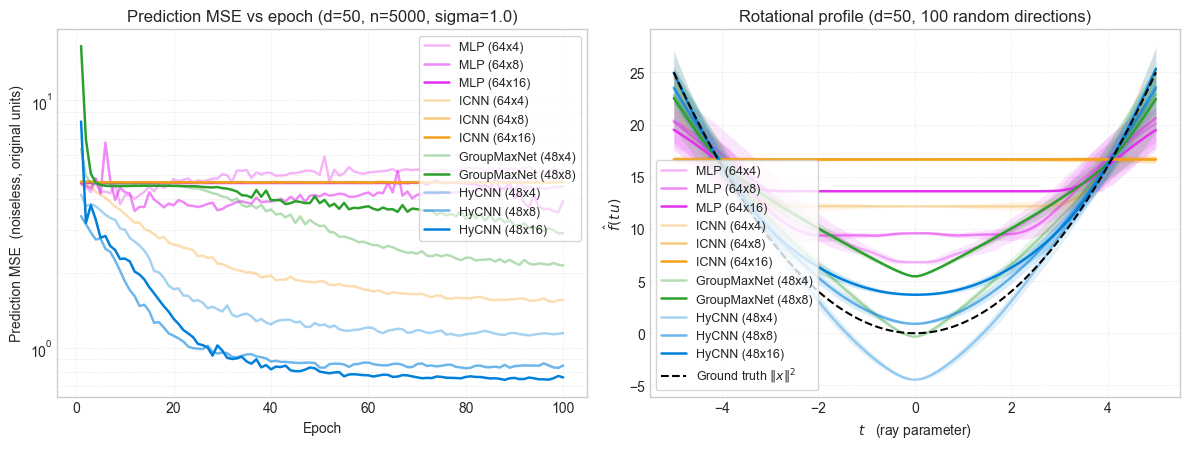

In [44]:
# =============================================================================
# 7. Rotational profile along random unit directions
# =============================================================================
@torch.no_grad()
def rotational_profile(model: nn.Module,
                        x_mean: torch.Tensor, x_std: torch.Tensor,
                        y_mean: torch.Tensor, y_std: torch.Tensor,
                        d: int,
                        x_range: tuple[float, float] = (-5.0, 5.0),
                        num_x: int = 100, num_directions: int = 100,
                        seed: int = 0,
                        device: torch.device = torch.device("cpu")):
    """Evaluate f_hat along num_directions random unit rays.

    Returns
    -------
    xs    : np.ndarray, shape (num_x,)
    preds : np.ndarray, shape (num_x, num_directions)
        preds[:, k] = f_hat(t * u_k) evaluated at xs.
    """
    rng = np.random.default_rng(seed)
    # Sample num_directions unit vectors u_k by normalising Gaussian samples:
    # this gives the uniform distribution on the sphere S^{d-1}.
    directions = rng.normal(size=(num_directions, d)).astype(np.float32)
    directions /= np.clip(np.linalg.norm(directions, axis=1, keepdims=True), 1e-12, None)

    xs = np.linspace(x_range[0], x_range[1], num_x, dtype=np.float32)
    # Build the (num_x, num_directions, d) tensor of ray points then flatten to (N, d).
    rays = (xs[:, None, None] * directions[None, :, :]).reshape(-1, d)
    rays_t = torch.from_numpy(rays).to(device)
    # Standardise inputs before feeding into the (standardised-output) model.
    rays_s = standardise(rays_t, x_mean.to(device), x_std.to(device))
    preds_s = model(rays_s)
    preds = destandardise(preds_s, y_mean.to(device), y_std.to(device))
    preds = preds.detach().cpu().numpy().reshape(num_x, num_directions)
    return xs, preds


# ---------------------------------------------------------------------------
# Build the combined figure (prediction loss + rotational profile), FIG_1 style.
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))

def _architecture_name(name: str) -> str:
    return name.split(" (", 1)[0]


def _opacity_by_architecture(names: Sequence[str], min_alpha: float = 0.35, max_alpha: float = 1.0) -> dict[str, float]:
    """Map each model to an alpha ranked by parameter count within its architecture."""
    counts = {
        name: sum(p.numel() for p in trained_models[name].parameters())
        for name in names
    }
    alphas: dict[str, float] = {}
    for arch in {_architecture_name(name) for name in names}:
        arch_names = [name for name in names if _architecture_name(name) == arch]
        arch_counts = [counts[name] for name in arch_names]
        lo, hi = min(arch_counts), max(arch_counts)
        for name in arch_names:
            if lo == hi:
                alphas[name] = max_alpha
            else:
                rank = (counts[name] - lo) / float(hi - lo)
                alphas[name] = min_alpha + rank * (max_alpha - min_alpha)
    return alphas


model_alpha = _opacity_by_architecture(DISPLAY_ORDER)

# ---- panel (a): prediction MSE vs epoch ----------------------------------
ax = axes[0]
for name in DISPLAY_ORDER:
    hist = pred_history[name]
    ax.plot(
        range(1, len(hist) + 1), hist,
        linewidth=1.8, color=color_for(name), alpha=model_alpha[name], label=name,
    )
ax.set_xlabel("Epoch")
ax.set_ylabel(r"Prediction MSE  (noiseless, original units)")
ax.set_title(f"Prediction MSE vs epoch (d={D}, n={N_TRAIN}, sigma={NOISE_STD})")
ax.set_yscale("log")
ax.grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.6)
ax.legend(loc="best", fontsize=9, frameon=True)

# ---- panel (b): rotational profile ---------------------------------------
ax = axes[1]
for name in DISPLAY_ORDER:
    model = trained_models[name]
    xs, preds = rotational_profile(
        model, x_mean, x_std, y_mean, y_std,
        d=D, x_range=(-5.0, 5.0),
        num_x=100, num_directions=100, seed=0, device=device,
    )
    mean = preds.mean(axis=1)
    p10 = np.percentile(preds, 10, axis=1)
    p90 = np.percentile(preds, 90, axis=1)
    c = color_for(name)
    alpha = model_alpha[name]
    ax.plot(xs, mean, linewidth=1.8, color=c, alpha=alpha, label=name)
    ax.fill_between(xs, p10, p90, alpha=0.08 + 0.10 * alpha, color=c, linewidth=0.0)

# Ground truth: f(t*u) = t^2 for any unit direction u.
true_xs = np.linspace(-5.0, 5.0, 200)
ax.plot(true_xs, true_xs ** 2,
        color="black", linestyle="--", linewidth=1.5,
        label=r"Ground truth $\|x\|^2$")

ax.set_xlabel(r"$t$   (ray parameter)")
ax.set_ylabel(r"$\hat f(t\,u)$")
ax.set_title(f"Rotational profile (d={D}, 100 random directions)")
ax.grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.6)
ax.legend(loc="best", fontsize=9, frameon=True)

plt.tight_layout()
plt.show()
